# Aula 5 — Machine Learning
## *Ou: como preparar os dados para o computador aprender de verdade*

---

> **Data:** *(preencher)*  
> **Professor(a):** *(preencher)*

## 🤔 Antes de começar: você já treinou um modelo

Na **Aula 4** vocês pegaram o dataset de diamantes, traçaram uma reta e previram preços.

Aquilo já era Machine Learning — vocês só ainda não tinham chamado pelo nome.

Mas a gente cortou três cantos para chegar lá:

1. **Jogamos fora as colunas de texto** (`cut`, `color`, `clarity`) — o modelo só aceitava números.
2. **Deixamos variáveis em escalas completamente diferentes** convivendo no mesmo modelo.
3. **Avaliamos o modelo nos mesmos dados em que ele treinou** — ou seja, fizemos a prova com o gabarito na mão.

Hoje a gente resolve os três.

No fim da aula você vai ter o **fluxo completo** de um projeto de Machine Learning — o mesmo
que você vai repetir pelo resto da vida, com qualquer modelo e qualquer base.

---

## 1. O que é Machine Learning?

### A versão humana de aprender

Quando você era criança, como aprendeu que um cachorro é um cachorro?

Alguém ficou te mostrando vários animais diferentes e dizendo: *"Esse é cachorro. Esse também. Aquele é gato, não é cachorro."*

Com o tempo, você internalizou um padrão: *"cachorro tem focinho assim, late, tem 4 patas..."* — e hoje você reconhece um cachorro sem precisar que ninguém te diga.

**Machine Learning funciona exatamente assim, mas para computadores.**

### A definição (simples)

> Machine Learning (ou Aprendizado de Máquina) é uma forma de ensinar o computador a encontrar padrões em dados, sem precisar programar explicitamente cada regra.

Em vez de você dizer ao computador *"se o diamante tiver mais de 2 quilates E a cor for D, então custa acima de R$ 30.000"*, você simplesmente mostra vários exemplos de diamantes com seus preços — e o computador **aprende sozinho** qual é a relação.

### Comparando: a abordagem antiga vs ML

| Abordagem Tradicional | Machine Learning |
|---|---|
| Você escreve as regras | O computador descobre as regras |
| Funciona só para casos previstos | Funciona para casos novos |
| Difícil de atualizar | Aprende com novos dados |

---

## 2. O que é um "Modelo"?

### A analogia do funcionário novo

Imagina que você contratou alguém novo na empresa para avaliar propostas comerciais.

No primeiro dia, você senta com ele e mostra **100 propostas antigas** que já foram avaliadas, dizendo: *"Essa aqui foi aprovada, essa foi rejeitada, essa foi aprovada..."*

O funcionário estuda tudo aquilo, aprende o padrão de decisão da empresa, e depois começa a avaliar **propostas novas** por conta própria.

**Esse funcionário é o modelo de Machine Learning.**

- O processo de estudo = **treinamento**
- As 100 propostas antigas = **dados de treinamento**
- A avaliação das propostas novas = **previsão (predição)**

### Formalizando

Um **modelo** é uma função matemática (não se assuste!) que recebe características de uma coisa como entrada e retorna uma previsão como saída.

```
Características do diamante → [MODELO] → Preço previsto
(quilate, cor, corte...)               (R$ 12.500)
```

> 💡 **Você já tem um.** A reta da Aula 4 (`preço = a × quilate + b`) é exatamente isso: uma
> função que recebe características e devolve uma previsão. A Regressão Linear foi o seu
> primeiro modelo — hoje vamos entender o processo que existe em volta dele.

---


## 3. Treino vs. Teste — por que dividir os dados?

### A analogia da prova

Imagina que o professor vai aplicar uma prova com 100 questões.

Dois alunos estudam de formas diferentes:

- **Aluno A:** decora as respostas das 100 questões que serão cobradas.
- **Aluno B:** estuda o conteúdo de verdade.

Na prova, o Aluno A vai bem. Mas se o professor mudar as questões? O Aluno A se dá mal.

O mesmo problema acontece em ML. Se o modelo *decorar* os dados de treino em vez de aprender o padrão real, ele vai falhar nos dados novos.

### A solução: separar treino e teste

Por isso, **nunca treinamos e avaliamos o modelo nos mesmos dados**. A lógica é:

1. Pegamos nosso conjunto de dados completo
2. Separamos uma parte para **treinar** (o modelo aprende com esses)
3. Guardamos outra parte para **testar** (o modelo nunca viu esses — é a "prova" real)

```
Dados completos (100%)
├── Treino (80%) → o modelo aprende aqui
└── Teste  (20%) → avaliamos se ele aprendeu de verdade
```

A divisão mais comum é **80% treino / 20% teste**.

---

## 4. Nosso dataset: Diamantes 💎

Vamos trabalhar com o famoso dataset **diamonds**, que contém informações sobre ~54.000 diamantes.

### Variáveis do dataset:

| Coluna | O que é |
|---|---|
| `carat` | Peso do diamante em quilates (tamanho) |
| `cut` | Qualidade do corte (Fair, Good, Very Good, Premium, Ideal) |
| `color` | Cor (J = pior → D = melhor) |
| `clarity` | Clareza/pureza (I1 = pior → IF = melhor) |
| `depth` | Profundidade percentual |
| `table` | Largura do topo em relação ao ponto mais largo |
| `x`, `y`, `z` | Dimensões físicas em mm |
| `price` | **Preço em dólares (nosso alvo!)** |

**Nosso objetivo:** prever o preço (`price`) a partir das outras características.

Vamos carregar os dados:

In [1]:
# Importando as bibliotecas que vamos usar
import shutil
import urllib.request
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Na primeira vez a base é baixada para data_raw/ (o original, que fica de
# referência) e copiada para data/ (a cópia de trabalho, que é a que vamos usar).
# Bagunçou a base? Apague data/diamonds.csv e rode esta célula de novo.
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv'
Path('data_raw').mkdir(exist_ok=True)
Path('data').mkdir(exist_ok=True)

if not Path('data_raw/diamonds.csv').exists():
    print('Baixando diamonds.csv...')
    urllib.request.urlretrieve(url, 'data_raw/diamonds.csv')
if not Path('data/diamonds.csv').exists():
    shutil.copy('data_raw/diamonds.csv', 'data/diamonds.csv')

df = pd.read_csv('data/diamonds.csv')

# Primeiras linhas
df.head()

Baixando diamonds.csv...


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [2]:
# Quantos diamantes temos?
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Linhas: 53940
Colunas: 10


In [3]:
# Informações gerais: tipos de dados e valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [4]:
# Estatísticas básicas das colunas numéricas
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### Exploração rápida: entendendo os dados visualmente

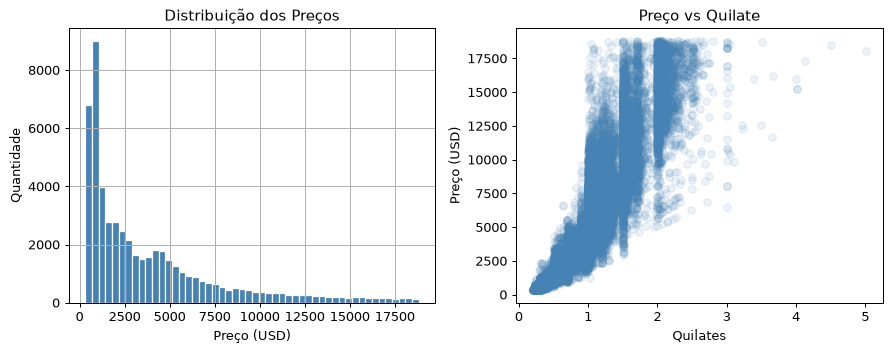

In [5]:
# Distribuição do preço
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['price'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Distribuição dos Preços')
plt.xlabel('Preço (USD)')
plt.ylabel('Quantidade')

# Preço vs Quilate
plt.subplot(1, 2, 2)
plt.scatter(df['carat'], df['price'], alpha=0.1, color='steelblue')
plt.title('Preço vs Quilate')
plt.xlabel('Quilates')
plt.ylabel('Preço (USD)')

plt.tight_layout()
plt.show()

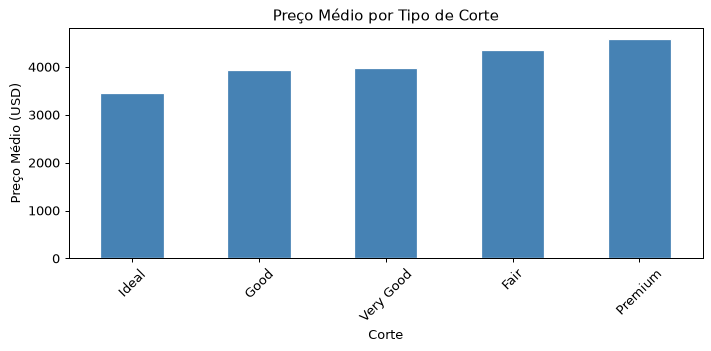

In [6]:
# Preço médio por qualidade de corte
plt.figure(figsize=(8, 4))
df.groupby('cut')['price'].mean().sort_values().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Preço Médio por Tipo de Corte')
plt.xlabel('Corte')
plt.ylabel('Preço Médio (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Observação curiosa:** diamantes com corte "Ideal" não são os mais caros em média. Isso acontece porque diamantes menores (mais baratos) tendem a ter cortes mais elaborados. Isso mostra que dados escondem histórias — e é por isso que análise exploratória importa!

---

## 5. Problema: os dados não estão prontos para o modelo 😬

Vamos olhar os tipos de dado de cada coluna:

In [7]:
df.dtypes

carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

Percebeu o problema?

As colunas `cut`, `color` e `clarity` são do tipo **`category`** — ou seja, são textos/categorias.

E modelos de Machine Learning trabalham com **números**. Eles não sabem o que significa "Ideal" ou "Good".

É como tentar somar "maçã" + "laranja". Não funciona.

**Precisamos transformar texto em número. Esse processo se chama: Pré-processamento.**

---

## 6. Pré-processamento de Dados

O pré-processamento é a etapa em que deixamos os dados no formato que o modelo consegue entender e trabalhar bem.

São dois grandes passos:
1. **Encoding** → transformar categorias em números
2. **Scaling** → colocar todas as variáveis na mesma escala

---

### 6.1. Encoding — transformando texto em número

#### O que é?

Imagine que você vai preencher um formulário e precisa colocar seu estado civil. Em vez de escrever "casado", você marca a opção **2** (onde: 1=solteiro, 2=casado, 3=divorciado).

Isso é encoding: substituir categorias por números.

#### Dois tipos principais:

**Label Encoding** — atribui um número para cada categoria:
```
Fair → 0
Good → 1
Very Good → 2
Premium → 3
Ideal → 4
```

✅ Funciona bem quando as categorias têm uma ordem natural (como qualidade: ruim → bom → ótimo)

**One-Hot Encoding** — cria uma coluna separada para cada categoria, com 0 ou 1:
```
         cut_Fair  cut_Good  cut_VeryGood  cut_Premium  cut_Ideal
diamante1    0         0           0            1            0
diamante2    0         0           0            0            1
```

✅ Funciona bem quando as categorias **não têm ordem** (como cor de carro: azul, verde, vermelho)

No nosso caso, as três colunas (`cut`, `color`, `clarity`) têm uma ordem natural (de pior para melhor), então vamos usar Label Encoding.

In [8]:
# Importando o LabelEncoder do scikit-learn
from sklearn.preprocessing import LabelEncoder

# Fazemos uma cópia do dataframe para não bagunçar o original
df_modelo = df.copy()

# Criamos um encoder
le = LabelEncoder()

# Aplicamos nas colunas categóricas
colunas_categoricas = ['cut', 'color', 'clarity']

for coluna in colunas_categoricas:
    df_modelo[coluna] = le.fit_transform(df_modelo[coluna])
    print(f"Coluna '{coluna}': {df[coluna].unique()} → {df_modelo[coluna].unique()}")

Coluna 'cut': <StringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str → [2 3 1 4 0]
Coluna 'color': <StringArray>
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Length: 7, dtype: str → [1 5 6 4 2 3 0]
Coluna 'clarity': <StringArray>
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Length: 8, dtype: str → [3 2 4 5 7 6 0 1]


In [9]:
# Conferindo como ficou
df_modelo.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


Agora todas as colunas são numéricas. ✅

---

### 6.2. Scaling — colocando tudo na mesma escala

#### Por que isso importa? Uma analogia

Imagine que você vai avaliar jogadores de futebol usando duas métricas:
- **Gols marcados:** varia de 0 a 50 na temporada
- **Passes certos (%):** varia de 0 a 100

Se você simplesmente somar as duas métricas, os passes vão dominar o resultado só por terem escala maior — mesmo que gols sejam mais importantes!

O mesmo acontece nos modelos de ML. Se uma variável vai de 0 a 1 e outra vai de 0 a 10.000, o modelo pode dar mais atenção à segunda só por causa da escala — não porque ela seja mais relevante.

#### StandardScaler: a solução

O **StandardScaler** transforma cada variável para que ela tenha:
- Média = 0
- Desvio padrão = 1

Na prática, ele recalcula cada valor assim:
```
valor_novo = (valor_original - média) / desvio_padrão
```

Não precisa decorar a fórmula. O importante é entender o efeito: **todos ficam na mesma escala**.

In [10]:
# Antes do scaling: vejamos as escalas das variáveis
df_modelo.describe().loc[['mean', 'std', 'min', 'max']]

,carat,cut,color,clarity,depth,table,price,x,y,z
mean,0.797940,2.553003,2.594197,3.835150,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.027708,1.701105,1.724591,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,0.000000,0.000000,0.000000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
max,5.010000,4.000000,6.000000,7.000000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


Olha a diferença de escala: `price` vai até 18.823, enquanto `carat` vai até 5.01. Isso é exatamente o problema que o scaling resolve.

---

## 7. Separando Features e Target

Antes de treinar qualquer coisa, precisamos separar:
- **Features (X):** as colunas que vamos usar como entrada (as características do diamante)
- **Target (y):** a coluna que queremos prever (o preço)

É como separar as perguntas da prova (X) do gabarito (y).

In [11]:
# Separando features (X) e target (y)
X = df_modelo.drop(columns=['price'])   # tudo MENOS o preço
y = df_modelo['price']                  # só o preço

print(f"Formato de X: {X.shape}")  # (linhas, colunas de features)
print(f"Formato de y: {y.shape}")  # (linhas,)

X.head()

Formato de X: (53940, 9)
Formato de y: (53940,)


,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,2,1,3,61.5,55.0,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,4.34,4.35,2.75


---

## 8. Separando Treino e Teste

Lembra da analogia do Aluno A e do Aluno B? Agora vamos aplicar na prática.

In [12]:
from sklearn.model_selection import train_test_split

# Separando 80% para treino e 20% para teste
# random_state=42 garante que a divisão seja sempre a mesma (reprodutibilidade)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% para teste
    random_state=42      # semente aleatória (para reproduzir o mesmo resultado)
)

print(f"Treino: {X_train.shape[0]} diamantes")
print(f"Teste:  {X_test.shape[0]} diamantes")

Treino: 43152 diamantes
Teste:  10788 diamantes


---

## 9. Aplicando o Scaling (só nos dados de treino!)

⚠️ **Atenção — armadilha clássica de iniciante:**

O scaling deve ser **ajustado (fit) apenas nos dados de treino** e depois **aplicado (transform) nos dados de teste**.

Por quê? Imagine que você está participando de uma seletiva de empresa. A banca decide a média e o desvio padrão com base nos candidatos que ela já avaliou (treino). Quando você chega (teste), é avaliado com o mesmo critério — não com um critério novo feito só para você.

Se você ajustar o scaler no conjunto de teste também, estaria "vazando" informação do futuro para o passado — o modelo ficaria com vantagem injusta na avaliação.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform: aprende a escala COM os dados de treino E já transforma
X_train_scaled = scaler.fit_transform(X_train)

# transform: aplica a mesma escala nos dados de teste (sem reaprender)
X_test_scaled = scaler.transform(X_test)

print("Scaling aplicado com sucesso! ✅")
print(f"Média das features após scaling (deve ser ~0): {X_train_scaled.mean(axis=0).round(2)}")

Scaling aplicado com sucesso! ✅
Média das features após scaling (deve ser ~0): [-0.  0. -0.  0. -0. -0. -0. -0.  0.]


---

## 10. Aprendizado Supervisionado

Antes de treinar o modelo, vale entender o conceito por trás.

### O que é aprendizado supervisionado?

É o tipo mais comum de Machine Learning. A ideia é simples:

> Você fornece ao modelo **exemplos com respostas corretas** (dados rotulados), e ele aprende a relação entre as entradas e as saídas.

Como um professor que dá exercícios já resolvidos para o aluno estudar — e depois cobra uma prova.

### Dois tipos principais:

| Tipo | Quando usar | Exemplo |
|---|---|---|
| **Regressão** | Prever um número | Prever preço, salário, temperatura |
| **Classificação** | Prever uma categoria | Spam ou não spam, aprovado ou reprovado |

No nosso caso, queremos prever o **preço** (um número) — então é um problema de **Regressão**.

---

## 11. Finalmente: treinando o modelo

Agora sim. Os dados estão codificados, na mesma escala e separados em treino e teste.

E qual modelo vamos usar? O **mesmo da Aula 4** — Regressão Linear. A diferença não está no
modelo, está em **tudo o que fizemos antes dele**:

| | Aula 4 | Aula 5 (hoje) |
|---|---|---|
| Colunas usadas | só as numéricas | todas, com as de texto codificadas |
| Escala | cada uma na sua | todas padronizadas |
| Avaliação | nos próprios dados de treino | em dados que o modelo **nunca viu** |

Essa última linha é a mais importante: o R² que vai aparecer agora é uma nota **honesta**.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# O mesmo modelo da Aula 4 — agora sobre os dados devidamente preparados
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

# Prevendo em dados que o modelo nunca viu
y_pred = modelo.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MAE (Erro Médio Absoluto): ${mae:,.0f}")
print(f"R² (quanto o modelo explica): {r2:.2%}")

MAE (Erro Médio Absoluto): $859
R² (quanto o modelo explica): 88.51%


## 12. Recapitulando o Fluxo Completo

Vamos visualizar o que fizemos hoje:

```
📊 DADOS BRUTOS
    ↓
🔍 EXPLORAÇÃO (EDA)
    ↓
🔧 PRÉ-PROCESSAMENTO
    ├── Encoding (texto → número)
    └── Scaling (equalizar escalas)
    ↓
✂️  SEPARAÇÃO (Treino / Teste)
    ↓
🧠 TREINAMENTO DO MODELO
    ↓
🔮 PREVISÕES
    ↓
📏 AVALIAÇÃO (MAE, R²)
    ↓
💡 INTERPRETAÇÃO DOS COEFICIENTES   ← como na Aula 4
```

Esse é o **fluxo padrão de um projeto de Machine Learning**. Você vai usar isso o resto da vida!

---

## 🏋️ Exercícios — Mão na Massa!

Agora é a sua vez. Os exercícios estão divididos em três níveis. Tente fazer todos!

---

### 🟢 Nível Fácil — Modificação simples

#### Exercício 1
O modelo foi treinado com 80% dos dados. Tente mudar para **70% de treino e 30% de teste**.
- O MAE melhorou ou piorou?
- O que isso nos diz sobre a relação entre quantidade de dados de treino e qualidade do modelo?

In [15]:
# Exercício 1 - 70% treino / 30% teste
X_tr70, X_te30, y_tr70, y_te30 = train_test_split(X, y, test_size=0.3, random_state=42)

# O scaling precisa ser refeito: a escala é aprendida no treino, que agora é outro
scaler_70 = StandardScaler()
X_tr70_sc = scaler_70.fit_transform(X_tr70)
X_te30_sc = scaler_70.transform(X_te30)

modelo_70 = LinearRegression()
modelo_70.fit(X_tr70_sc, y_tr70)
y_pred_70 = modelo_70.predict(X_te30_sc)

mae_70 = mean_absolute_error(y_te30, y_pred_70)
r2_70  = r2_score(y_te30, y_pred_70)

print(f"{'Divisão':<10} {'Treino':>10} {'Teste':>10} {'MAE':>10} {'R²':>9}")
print("-" * 52)
print(f"{'80/20':<10} {X_train.shape[0]:>10,} {X_test.shape[0]:>10,} {mae:>9,.0f} {r2:>9.2%}")
print(f"{'70/30':<10} {X_tr70.shape[0]:>10,} {X_te30.shape[0]:>10,} {mae_70:>9,.0f} {r2_70:>9.2%}")
print()
print(f"Diferença no MAE: ${mae_70 - mae:,.0f}")

Divisão        Treino      Teste        MAE        R²
----------------------------------------------------
80/20          43,152     10,788       859    88.51%
70/30          37,758     16,182       856    88.64%

Diferença no MAE: $-2


> **✅ Resposta**
>
> **Praticamente nada mudou:** o MAE foi de US$ 859 (80/20) para US$ 856 (70/30) e o R² de
> 88,51% para 88,64%. Uma diferença de US$ 2 no MAE é ruído, não melhora.
>
> **Por quê:** mesmo com 70%, sobram 37.758 diamantes no treino. Para uma regressão linear com
> 9 features isso é muito mais do que o suficiente, e o modelo já aprendeu tudo o que conseguia
> aprender.
>
> A relação entre quantidade de dados e qualidade do modelo tem **retorno decrescente**: os
> primeiros milhares de exemplos valem muito, os seguintes valem cada vez menos. E o lado bom da
> troca é que o teste ficou maior (16.182 diamantes), o que dá uma estimativa mais estável do erro.
>
> Isso só vale porque a base é grande. Com 200 linhas, tirar 10% do treino faria diferença.

#### Exercício 2
Treine o modelo **sem aplicar o scaling** (use `X_train` e `X_test` diretamente, sem passar pelo `StandardScaler`).
- Compare o MAE e R² com e sem scaling.
- O que você conclui?

In [16]:
# Exercício 2 - treinando SEM scaling (X_train e X_test crus)
modelo_sem = LinearRegression()
modelo_sem.fit(X_train, y_train)
y_pred_sem = modelo_sem.predict(X_test)

mae_sem = mean_absolute_error(y_test, y_pred_sem)
r2_sem  = r2_score(y_test, y_pred_sem)

print(f"{'Modelo':<20} {'MAE':>10} {'R²':>10}")
print("-" * 42)
print(f"{'COM scaling':<20} {mae:>9,.2f} {r2:>10.4%}")
print(f"{'SEM scaling':<20} {mae_sem:>9,.2f} {r2_sem:>10.4%}")
print()

# O desempenho é o mesmo, mas os coeficientes não são:
comparacao_coef = pd.DataFrame({
    'Feature':          X.columns,
    'Coef COM scaling': modelo.coef_.round(1),
    'Coef SEM scaling': modelo_sem.coef_.round(1),
})
print(comparacao_coef.to_string(index=False))

Modelo                      MAE         R²
------------------------------------------
COM scaling             858.71   88.5140%
SEM scaling             858.71   88.5140%

Feature  Coef COM scaling  Coef SEM scaling
  carat            5203.3           10992.9
    cut              73.9              72.0
  color            -456.4            -268.7
clarity             493.8             286.3
  depth            -222.4            -155.7
  table            -210.4             -94.4
      x           -1310.9           -1170.2
      y              27.3              23.8
      z               8.6              12.2


> **✅ Resposta**
>
> **MAE e R² são exatamente iguais:** US$ 858,71 e 88,5140% nos dois casos.
>
> A regressão linear encontra os coeficientes por uma fórmula fechada (mínimos quadrados).
> Multiplicar uma coluna por uma constante apenas divide o coeficiente dela pela mesma constante,
> e a previsão final não muda.
>
> **O que muda são os coeficientes.** O de `carat` sai de 10.993 sem scaling ("dólares por
> quilate") para 5.203 com scaling ("dólares por desvio-padrão de quilate").
>
> Então por que fazer scaling? Por dois motivos:
> 1. com tudo na mesma escala, os coeficientes ficam comparáveis entre si e dá para dizer qual
>    variável pesa mais;
> 2. **outros modelos precisam de verdade**: KNN, SVM, redes neurais e qualquer coisa com
>    regularização (Ridge, Lasso) ou gradiente descendente. Nesses, esquecer o scaling muda o
>    resultado.
>
> Ou seja, na regressão linear o scaling é um hábito barato e útil, não uma obrigação.

---

### 🟡 Nível Médio — Aplicar sozinho

#### Exercício 3
Remova as colunas `x`, `y` e `z` do conjunto de features (argumento `drop` no pandas) e retreine o modelo.
- O desempenho mudou?
- Faz sentido remover essas colunas? Por quê?

*Dica:* `x`, `y` e `z` são as dimensões físicas do diamante. Quilate (`carat`) também mede o tamanho. Será que estamos dando informação redundante ao modelo?

In [17]:
# Exercício 3 - removendo as dimensões físicas x, y e z
X_sem_xyz = X.drop(columns=['x', 'y', 'z'])

X_tr, X_te, y_tr, y_te = train_test_split(X_sem_xyz, y, test_size=0.2, random_state=42)

scaler_3 = StandardScaler()
X_tr_sc = scaler_3.fit_transform(X_tr)
X_te_sc = scaler_3.transform(X_te)

modelo_3 = LinearRegression()
modelo_3.fit(X_tr_sc, y_tr)
y_pred_3 = modelo_3.predict(X_te_sc)

mae_3 = mean_absolute_error(y_te, y_pred_3)
r2_3  = r2_score(y_te, y_pred_3)

print(f"{'Modelo':<28} {'Features':>9} {'MAE':>10} {'R²':>9}")
print("-" * 60)
print(f"{'Com x, y, z':<28} {X.shape[1]:>9} {mae:>9,.0f} {r2:>9.2%}")
print(f"{'Sem x, y, z':<28} {X_sem_xyz.shape[1]:>9} {mae_3:>9,.0f} {r2_3:>9.2%}")
print()

# Por que elas eram dispensáveis? Olhe a correlação delas com carat:
print("Correlação com carat:")
print(df[['carat', 'x', 'y', 'z']].corr()['carat'].round(3).to_string())

Modelo                        Features        MAE        R²
------------------------------------------------------------
Com x, y, z                          9       859    88.51%
Sem x, y, z                          6       930    88.05%

Correlação com carat:
carat    1.000
x        0.975
y        0.952
z        0.953


> **✅ Resposta**
>
> **O desempenho cai pouco:** MAE de US$ 859 para US$ 930 e R² de 88,51% para 88,05%. Saíram três
> das nove features e o modelo perdeu meio ponto percentual de R².
>
> **Faz sentido remover?** Sim, e a correlação explica: `x`, `y` e `z` têm 0,975, 0,952 e 0,953 de
> correlação com `carat`. As quatro medem a mesma coisa, o tamanho da pedra. Manter as quatro é
> dar a mesma informação ao modelo quatro vezes.
>
> O ganho de tirar: coeficientes mais estáveis e interpretáveis (é o problema de
> multicolinearidade que apareceu na Aula 4), modelo mais simples e menos colunas para coletar e
> manter.
>
> O custo: aquele MAE US$ 71 maior. Se o objetivo é só prever, dá para ficar com as nove. Se o
> objetivo é **explicar** o que forma o preço, o modelo enxuto é melhor.

#### Exercício 4
Faça um gráfico de barras mostrando os **5 maiores erros absolutos** do modelo (os 5 diamantes onde ele mais errou).
- Mostre o ID do diamante, o preço real e o preço previsto.
- Esses diamantes têm algo em comum? (olhe os dados originais usando o índice)

Os 5 maiores erros absolutos:
       preco_real  preco_previsto  erro_abs
25998       15223         32293.0   17070.0
25999       15223         31834.0   16611.0
26444       15984         32330.0   16346.0
24328       12587         27540.0   14953.0
21862        9925         23416.0   13491.0

Como são esses diamantes na base original:
       carat        cut color clarity  depth  table  price
25998   4.01    Premium     I      I1   61.0   61.0  15223
25999   4.01    Premium     J      I1   62.5   62.0  15223
26444   4.00  Very Good     I      I1   63.3   58.0  15984
24328   3.50      Ideal     H      I1   62.8   57.0  12587
21862   3.01    Premium     F      I1   62.2   56.0   9925

Quilate médio dos 5 piores erros: 3.71
Quilate médio da base inteira:    0.80


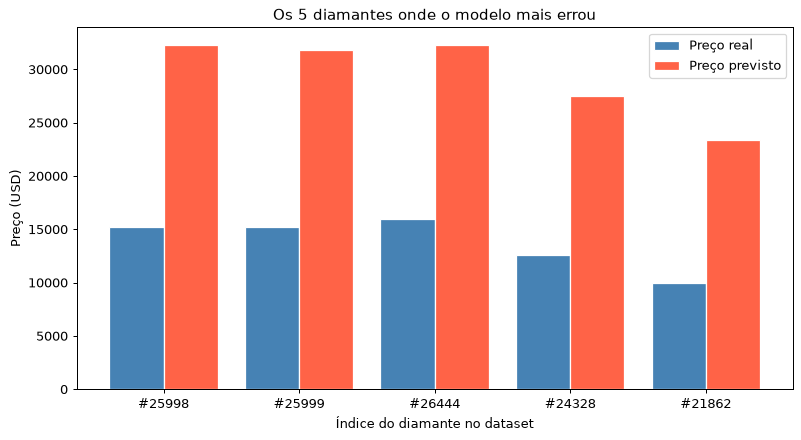

In [18]:
# Exercício 4 - os 5 diamantes em que o modelo mais errou
erros = pd.DataFrame({
    'preco_real':     y_test.values,
    'preco_previsto': y_pred.round(0),
}, index=y_test.index)
erros['erro_abs'] = (erros['preco_real'] - erros['preco_previsto']).abs()

top5 = erros.sort_values('erro_abs', ascending=False).head(5)
print("Os 5 maiores erros absolutos:")
print(top5.to_string())
print()

print("Como são esses diamantes na base original:")
print(df.loc[top5.index, ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price']].to_string())
print()
print(f"Quilate médio dos 5 piores erros: {df.loc[top5.index, 'carat'].mean():.2f}")
print(f"Quilate médio da base inteira:    {df['carat'].mean():.2f}")

# Gráfico de barras: real x previsto para os 5 piores
posicoes = range(len(top5))
largura = 0.4

plt.figure(figsize=(9, 5))
plt.bar([p - largura/2 for p in posicoes], top5['preco_real'], largura,
        label='Preço real', color='steelblue', edgecolor='white')
plt.bar([p + largura/2 for p in posicoes], top5['preco_previsto'], largura,
        label='Preço previsto', color='tomato', edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(list(posicoes), [f'#{i}' for i in top5.index])
plt.xlabel('Índice do diamante no dataset')
plt.ylabel('Preço (USD)')
plt.title('Os 5 diamantes onde o modelo mais errou')
plt.legend()
plt.tight_layout()
plt.show()

> **✅ Resposta**
>
> **Sim, os cinco têm muito em comum:**
>
> | | erro | quilate | clareza | real | previsto |
> |---|---|---|---|---|---|
> | #25998 | US$ 17.070 | 4,01 | I1 | 15.223 | 32.293 |
> | #25999 | US$ 16.611 | 4,01 | I1 | 15.223 | 31.834 |
> | #26444 | US$ 16.346 | 4,00 | I1 | 15.984 | 32.330 |
> | #24328 | US$ 14.953 | 3,50 | I1 | 12.587 | 27.540 |
> | #21862 | US$ 13.491 | 3,01 | I1 | 9.925  | 23.416 |
>
> Todos são **diamantes enormes** (3,0 a 4,0 quilates, contra 0,80 de média na base) e todos têm
> clareza **I1**, a pior da escala. E em todos o modelo **previu para cima**, chegando a estimar
> US$ 32.293 numa pedra que vale US$ 15.223.
>
> **Por que isso acontece:** o modelo é dominado pelo `carat`. Ele aprendeu "grande = caro" e
> aplica essa regra sem ressalvas. Só que um diamante de 4 quilates cheio de inclusões vale uma
> fração do que valeria um limpo do mesmo tamanho.
>
> Falta ao modelo linear a noção de **interação**: o efeito do tamanho depende da qualidade. Uma
> reta não consegue representar "grande é caro, exceto quando a clareza é ruim". Árvores e modelos
> de boosting capturam esse tipo de regra com facilidade.

---

### 🔴 Nível Difícil — Pensamento crítico

#### Exercício 5
O nosso modelo tem um R² de aproximadamente 0.88. Isso parece bom!

Mas olhando o gráfico de previsões vs valores reais, percebemos que o modelo erra mais para diamantes caros (acima de $10.000).

**Hipótese:** a distribuição do preço é assimétrica (tem uma cauda longa à direita). Aplicar `log` no preço antes de treinar pode ajudar o modelo.

Tente:
1. Criar uma nova variável `y_log = np.log(y)`
2. Treinar o modelo com essa nova variável
3. Para comparar o MAE com o original, lembre de converter as previsões de volta com `np.exp(y_pred_log)`
4. O MAE melhorou?

*Dica:* para importar numpy, use `import numpy as np`

In [19]:
# Exercício 5 - Seu código aqui
import numpy as np

# 1) log do preço
y_log_train = np.log(y_train)

# 2) treina o modelo no log
modelo_log = LinearRegression()
modelo_log.fit(X_train_scaled, y_log_train)

# 3) prevê e volta para a escala de dólares
y_pred_log = modelo_log.predict(X_test_scaled)
y_pred_dolar = np.exp(y_pred_log)

mae_log = mean_absolute_error(y_test, y_pred_dolar)
r2_log  = r2_score(y_test, y_pred_dolar)

print(f"{'Modelo':<22} {'MAE':>10} {'R²':>9}  {'Previsões negativas':>20}")
print("-" * 66)
print(f"{'preço direto':<22} {mae:>9,.0f} {r2:>9.2%}  {(y_pred < 0).sum():>20,}")
print(f"{'log(preço)':<22} {mae_log:>9,.0f} {r2_log:>9.2%}  {(y_pred_dolar < 0).sum():>20,}")
print()

# 4) onde cada modelo erra: MAE por faixa de preço
faixas = pd.cut(y_test, [0, 1000, 2500, 5000, 10000, 20000],
                labels=['até 1k', '1k-2.5k', '2.5k-5k', '5k-10k', '10k+'])
por_faixa = pd.DataFrame({
    'faixa':      faixas.values,
    'erro_direto': (y_test.values - y_pred),
    'erro_log':    (y_test.values - y_pred_dolar),
})
resumo = por_faixa.groupby('faixa', observed=True).agg(
    n=('erro_direto', 'size'),
    mae_direto=('erro_direto', lambda e: e.abs().mean()),
    mae_log=('erro_log', lambda e: e.abs().mean()),
).round(0)
print("MAE por faixa de preço:")
print(resumo.to_string())

Modelo                        MAE        R²   Previsões negativas
------------------------------------------------------------------
preço direto                 859    88.51%                   763
log(preço)                   686    86.91%                     0

MAE por faixa de preço:
            n  mae_direto  mae_log
faixa                             
até 1k   2967       522.0    125.0
1k-2.5k  2544       517.0    227.0
2.5k-5k  2400       781.0    539.0
5k-10k   1844      1032.0   1240.0
10k+     1033      2538.0   2784.0


> **✅ Resposta**
>
> **O MAE melhorou:** de US$ 859 para US$ 686, uma queda de 20%. E, de brinde, as **763 previsões
> negativas somem**, porque `exp()` nunca devolve número negativo.
>
> O R², em compensação, cai de 88,51% para 86,91%. Não é contradição: o modelo direto foi
> otimizado justamente para minimizar erro quadrático em dólares, que é o que o R² mede.
>
> **O detalhe mais interessante está no erro por faixa de preço:**
>
> | faixa | MAE preço direto | MAE log |
> |---|---|---|
> | até 1k | 522 | **125** |
> | 1k a 2,5k | 517 | **227** |
> | 2,5k a 5k | 781 | **539** |
> | 5k a 10k | **1.032** | 1.240 |
> | 10k+ | **2.538** | 2.784 |
>
> Treinar no log equivale a minimizar o erro **percentual**, e não o erro em dólares. Errar US$ 500
> num diamante de US$ 800 é um desastre; errar os mesmos US$ 500 num de US$ 15.000 é detalhe. O
> modelo do log leva isso em conta, acerta muito melhor os baratos (que são a maioria da base) e
> abre mão de um pouco de precisão nos caros.
>
> Qual escolher depende da pergunta: para uma loja que vende sobretudo pedras pequenas, o log é
> claramente melhor.

#### Exercício 6 (Bônus)

O dataset `diamonds` do seaborn não é o único dataset público interessante. Pesquise e carregue o dataset `tips` (gorjetas em restaurantes) com `sns.load_dataset('tips')`.

Aplique todo o pipeline que vimos hoje para prever o valor da gorjeta (`tip`) a partir das outras informações.

Perguntas para refletir:
- Quais variáveis mais influenciam a gorjeta?
- O modelo de regressão linear é adequado para esse problema?
- O R² é alto ou baixo? O que isso significa?

In [20]:
# Exercício 6 - o mesmo pipeline no dataset tips
tips = sns.load_dataset('tips')
print("Dataset tips:", tips.shape)
print(tips.head().to_string())
print()

# 1) encoding das colunas categóricas
tips_modelo = tips.copy()
for coluna in ['sex', 'smoker', 'day', 'time']:
    tips_modelo[coluna] = LabelEncoder().fit_transform(tips_modelo[coluna])

# 2) features e alvo
X_tips = tips_modelo.drop(columns=['tip'])
y_tips = tips_modelo['tip']

# 3) treino/teste
X_tips_tr, X_tips_te, y_tips_tr, y_tips_te = train_test_split(
    X_tips, y_tips, test_size=0.2, random_state=42)

# 4) scaling
scaler_tips = StandardScaler()
X_tips_tr_sc = scaler_tips.fit_transform(X_tips_tr)
X_tips_te_sc = scaler_tips.transform(X_tips_te)

# 5) modelo
modelo_tips = LinearRegression()
modelo_tips.fit(X_tips_tr_sc, y_tips_tr)
y_pred_tips = modelo_tips.predict(X_tips_te_sc)

mae_tips = mean_absolute_error(y_tips_te, y_pred_tips)
r2_tips  = r2_score(y_tips_te, y_pred_tips)

print(f"MAE: ${mae_tips:.2f}  (gorjeta média: ${y_tips.mean():.2f})")
print(f"R²:  {r2_tips:.2%}")
print()

coef_tips = pd.DataFrame({
    'Feature': X_tips.columns,
    'Coeficiente': modelo_tips.coef_.round(3),
}).sort_values('Coeficiente', key=abs, ascending=False)
print("Peso de cada variável (dados padronizados, então dá para comparar):")
print(coef_tips.to_string(index=False))

Dataset tips: (244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

MAE: $0.67  (gorjeta média: $3.00)
R²:  44.41%

Peso de cada variável (dados padronizados, então dá para comparar):
   Feature  Coeficiente
total_bill        0.822
      size        0.225
    smoker       -0.093
      time        0.027
       sex        0.016
       day       -0.006


> **✅ Resposta**
>
> **Resultado:** MAE de **US$ 0,67** sobre uma gorjeta média de US$ 3,00 (erro de uns 22%) e
> **R² de 44,41%**.
>
> **Quais variáveis importam:** `total_bill` domina com folga (coeficiente 0,822), seguida do
> tamanho da mesa, `size` (0,225). Todo o resto (fumante, dia, horário, sexo) fica perto de zero.
> Ou seja, gorjeta é basicamente uma porcentagem da conta, e o resto é detalhe.
>
> **A regressão linear é adequada?** Como ponto de partida, sim: a relação entre conta e gorjeta é
> de fato próxima de uma reta.
>
> **O R² é baixo?** Comparado aos 88% dos diamantes, sim. Mas o que sobra sem explicação aqui é
> comportamento humano: humor do cliente, qualidade do atendimento, hábito de arredondar o valor.
> Nada disso está na tabela. Em dados de comportamento, 44% costuma ser um resultado respeitável,
> enquanto 88% seria motivo de desconfiança.
>
> Um alerta metodológico: `tips` tem 244 linhas, então o teste ficou com 49. Com uma amostra desse
> tamanho, o R² varia bastante conforme o `random_state`. Aqui cross-validation (Aula 7) seria mais
> honesto do que um split único.

---

## 🎯 Resumo da Aula

Hoje você aprendeu:

| Conceito | Em uma frase |
|---|---|
| **Machine Learning** | Ensinar o computador a encontrar padrões em dados |
| **Modelo** | A "função" que transforma características em previsões |
| **Treino/Teste** | Dividir dados para avaliar o modelo em exemplos que ele nunca viu |
| **Encoding** | Transformar categorias (texto) em números |
| **Scaling** | Colocar todas as variáveis na mesma escala |
| **Aprendizado Supervisionado** | Treinar com exemplos que já têm a resposta correta |

> O modelo (**Regressão Linear**) e as métricas (**MAE**, **R²**) você já conhecia da **Aula 4**.
> O que mudou hoje foi o pipeline em volta deles — e é justamente isso que separa um número
> bonito de um número confiável.

---

*Boa sorte nos exercícios!*
